In [16]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/customer_clustered.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 9)


,name,age,gender,education,income,country,purchase_frequency,annual_spending,cluster
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,1
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,2
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,2
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0


In [19]:
segment_mapping = {
    0: "Premium",
    1: "Regular",
    2: "Budget"
}

df["segment"] = df["cluster"].map(segment_mapping)

print("Customer segments:")
print(df["segment"].value_counts())

Customer segments:
segment
Budget     446
Premium    292
Regular    262
Name: count, dtype: int64


In [17]:
cluster_counts = df["cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
cluster
0    292
1    262
2    446
Name: count, dtype: int64


In [18]:
cluster_percentages = (
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Cluster percentages:")
print(cluster_percentages.round(2))

Cluster percentages:
cluster
0    29.2
1    26.2
2    44.6
Name: proportion, dtype: float64


In [20]:
segment_profile = df.groupby("segment").agg(
    customer_count=("name", "count"),
    average_age=("age", "mean"),
    average_income=("income", "mean"),
    average_purchase_frequency=("purchase_frequency", "mean"),
    average_annual_spending=("annual_spending", "mean")
).round(2)

segment_profile

,customer_count,average_age,average_income,average_purchase_frequency,average_annual_spending
segment,,,,,
Budget,446,39.15,57163.59,0.29,4633.07
Premium,292,41.16,80638.28,0.76,13829.13
Regular,262,46.85,39070.67,0.78,13392.53


In [21]:
df.to_csv("../data/customer_segmented.csv", index=False)

print("Final customer segmentation saved successfully.")

Final customer segmentation saved successfully.


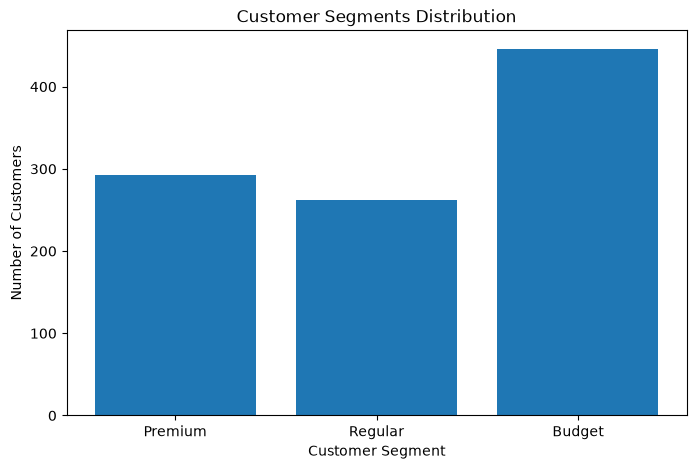

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

segment_counts = df["segment"].value_counts().reindex(
    ["Premium", "Regular", "Budget"]
)

plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

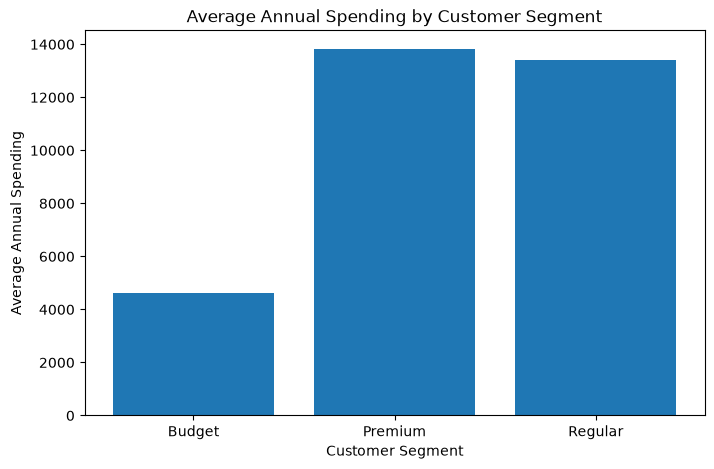

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_profile.index,
    segment_profile["average_annual_spending"]
)

plt.title("Average Annual Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Annual Spending")

plt.show()

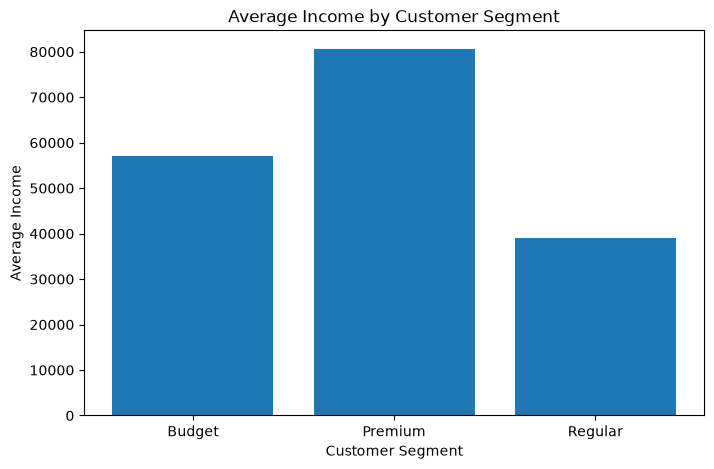

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_profile.index,
    segment_profile["average_income"]
)

plt.title("Average Income by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Income")

plt.show()

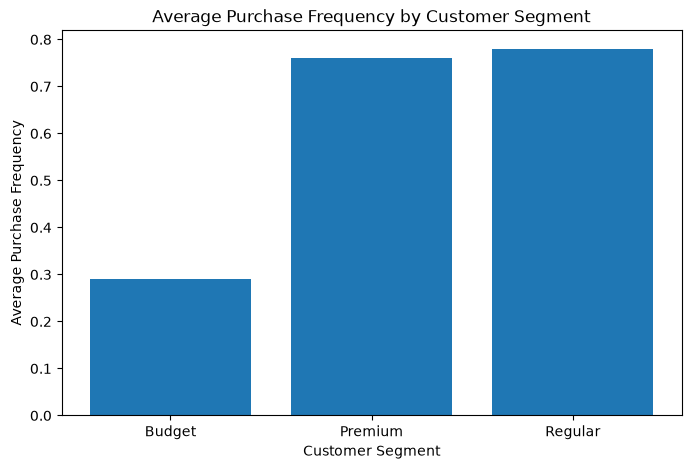

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_profile.index,
    segment_profile["average_purchase_frequency"]
)

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchase Frequency")

plt.show()